In [11]:
!pip install -q faiss-cpu sentence_transformers scikit-learn-intelex

In [ ]:
import warnings
import torch
import pandas as pd
import numpy as np
import faiss
import joblib
from transformers import pipeline
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
sns.set_style('whitegrid')

In [13]:
clf = joblib.load('logistic_regression_model.pkl')
vectorizer = joblib.load('tfidf_vectorizer.pkl')

train = pd.read_csv('train_lemmatized.csv').dropna(subset=['message_lemmatized', 'label'])
new_data = pd.read_csv('all_events.csv').dropna(subset=['description'])

In [14]:
embedding_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

bert_classifier = pipeline(
    "text-classification",
    model="MariaOnyshchuk/prop_xlmroberta",
    device=0 if device == 'cuda' else -1,
    return_all_scores=True
)


model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Device set to use cuda:0


In [15]:
documents = train['message_lemmatized'].tolist()
doc_labels = train['label'].tolist()

embeddings = embedding_model.encode(documents, batch_size=64, show_progress_bar=True)

dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings.astype('float32'))


Batches:   0%|          | 0/479 [00:00<?, ?it/s]

In [16]:
def batch_retrieve(texts, top_k=3):
    query_embeddings = embedding_model.encode(texts, batch_size=32, show_progress_bar=False)
    distances, indices = index.search(query_embeddings.astype('float32'), top_k)

    batch_retrieved = []
    for i in range(len(texts)):
        retrieved = []
        for idx, dist in zip(indices[i], distances[i]):
            retrieved.append({
                'text': documents[idx],
                'label': doc_labels[idx],
                'distance': float(dist)
            })
        batch_retrieved.append(retrieved)

    return batch_retrieved

In [17]:
def ensemble_classify(texts, batch_size=16):
    retrieved_docs_list = batch_retrieve(texts, top_k=3)

    bert_probs_all = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        batch_retrieved = retrieved_docs_list[i:i+batch_size]

        augmented_texts = []
        for text, retrieved in zip(batch_texts, batch_retrieved):
            context = "\n".join([doc['text'][:100] for doc in retrieved[:2]])
            augmented_texts.append(f"{context}\n\n{text}")

        batch_results = bert_classifier(augmented_texts, truncation=True, max_length=512)

        for result in batch_results:
            probs = np.array([score['score'] for score in result])
            bert_probs_all.append(probs)

    bert_probs_all = np.array(bert_probs_all)

    X_test = vectorizer.transform(texts)
    lr_probs = clf.predict_proba(X_test)

    ensemble_probs = 0.1 * bert_probs_all + 0.9 * lr_probs

    label_names = {0: 'misinformation', 1: 'propaganda', 2: 'opposition'}
    predictions = []

    for i in range(len(texts)):
        final_label_idx = np.argmax(ensemble_probs[i])
        predictions.append({
            'final_label': label_names[final_label_idx],
            'final_label_numeric': final_label_idx,
            'confidence': float(ensemble_probs[i][final_label_idx]),
            'bert_probs': bert_probs_all[i].tolist(),
            'lr_probs': lr_probs[i].tolist(),
            'ensemble_probs': ensemble_probs[i].tolist()
        })

    return predictions


In [18]:
new_texts = new_data['description'].tolist()
results = ensemble_classify(new_texts, batch_size=16)

results_df = pd.DataFrame(results)
results_df['date'] = pd.to_datetime(new_data['date'].values)
results_df['description'] = new_data['description'].values

results_df.to_csv('final_predictions.csv', index=False)
print(f"Processed {len(results_df)} messages")
results_df.head()


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Processed 414 messages


,final_label,final_label_numeric,confidence,bert_probs,lr_probs,ensemble_probs,date,description
0,misinformation,0,0.458787,"[0.8592730164527893, 0.10056877881288528, 0.04...","[0.4142888980852424, 0.32752538779785256, 0.25...","[0.4587873099219971, 0.30482972689935584, 0.23...",2022-02-24,"In an early morning address (just before 3am, ..."
1,propaganda,1,0.411836,"[0.16939061880111694, 0.33918777108192444, 0.4...","[0.357873554597291, 0.4199077767773209, 0.2222...","[0.33902526101767355, 0.4118357762077813, 0.24...",2022-02-25,"Ukraine’s President, Volodymyr Zelenskyy, give..."
2,misinformation,0,0.403273,"[0.30412620306015015, 0.3630940914154053, 0.33...","[0.4142888980852424, 0.32752538779785256, 0.25...","[0.40327262858273316, 0.33108225815960785, 0.2...",2022-02-26,Fierce fighting breaks out in Kyiv as Russian ...
3,misinformation,0,0.351418,"[0.17333762347698212, 0.3127896785736084, 0.51...","[0.37120480113976484, 0.3473284608282302, 0.28...","[0.3514180833734866, 0.34387458260276804, 0.30...",2022-02-27,Responding to claims that the Russia is “ready...
4,misinformation,0,0.439443,"[0.6658304929733276, 0.18017587065696716, 0.15...","[0.4142888980852424, 0.32752538779785256, 0.25...","[0.43944305757405094, 0.31279043608376406, 0.2...",2022-02-28,Forty Ukrainian civil society groups come toge...


In [19]:
print(f"{'='*60}")
print(f"CLASSIFICATION RESULTS")
print(f"{'='*60}")
print(f"Total messages: {len(results_df)}")
print(f"\nLabel Distribution:")
print(results_df['final_label'].value_counts())
print(f"\nAverage Confidence: {results_df['confidence'].mean():.4f}")
print(f"Median Confidence: {results_df['confidence'].median():.4f}")
print(f"\nConfidence by Label:")
print(results_df.groupby('final_label')['confidence'].agg(['mean', 'std', 'min', 'max']))


CLASSIFICATION RESULTS
Total messages: 414

Label Distribution:
final_label
misinformation    321
propaganda         65
opposition         28
Name: count, dtype: int64

Average Confidence: 0.4305
Median Confidence: 0.4205

Confidence by Label:
                    mean       std       min       max
final_label                                           
misinformation  0.417951  0.036422  0.351418  0.579657
opposition      0.443403  0.055292  0.351311  0.561925
propaganda      0.486943  0.094406  0.344846  0.704167


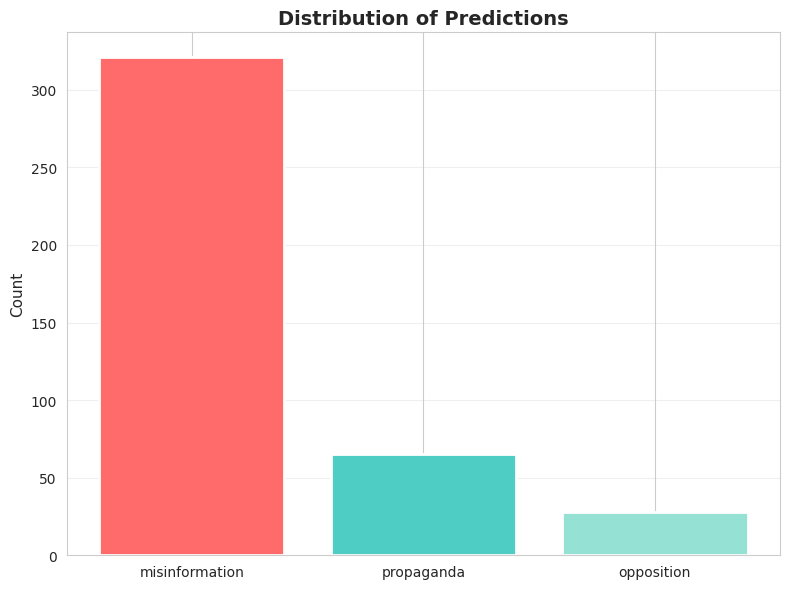

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))

label_counts = results_df['final_label'].value_counts()
colors = ['#FF6B6B' if l == 'misinformation' else '#4ECDC4' if l == 'propaganda' else '#95E1D3'
          for l in label_counts.index]
ax.bar(label_counts.index, label_counts.values, color=colors, edgecolor='white', linewidth=2)
ax.set_title('Distribution of Predictions', fontsize=14, fontweight='bold')
ax.set_ylabel('Count', fontsize=11)
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('distribution_predictions.png', dpi=300, bbox_inches='tight')
plt.show()


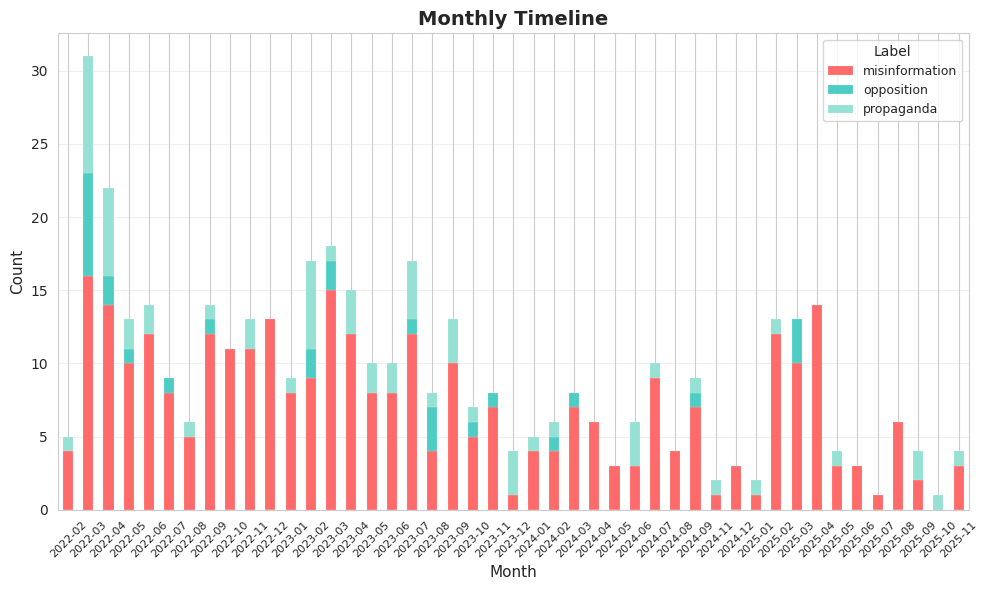

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))

results_df['month'] = results_df['date'].dt.to_period('M')
monthly_counts = results_df.groupby(['month', 'final_label']).size().unstack(fill_value=0)
monthly_counts.plot(kind='bar', stacked=True, ax=ax,
                    color=['#FF6B6B', '#4ECDC4', '#95E1D3'], edgecolor='white', linewidth=0.1)
ax.set_title('Monthly Timeline', fontsize=14, fontweight='bold')
ax.set_ylabel('Count', fontsize=11)
ax.set_xlabel('Month', fontsize=11)
ax.legend(title='Label', fontsize=9)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('monthly_timeline.png', dpi=300, bbox_inches='tight')
plt.show()


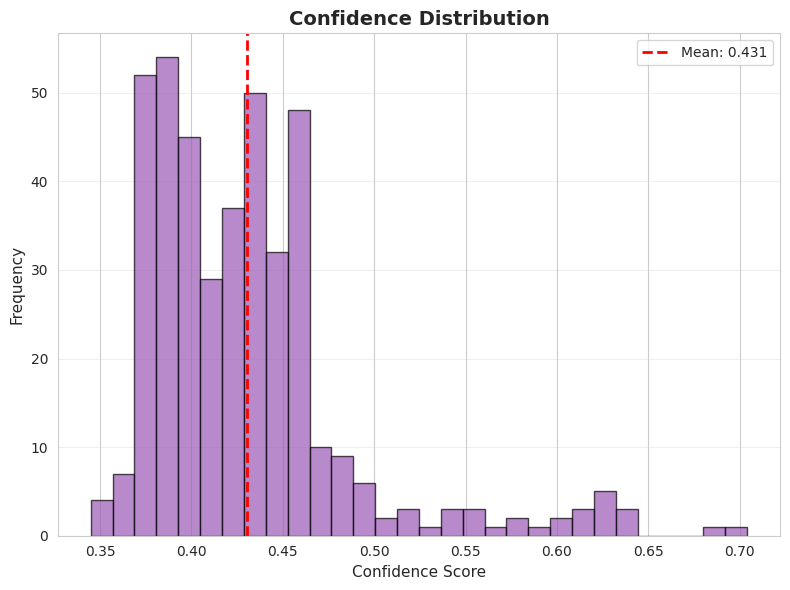

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(results_df['confidence'], bins=30, color='#9b59b6', edgecolor='black', alpha=0.7)
ax.set_title('Confidence Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Confidence Score', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.axvline(results_df['confidence'].mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {results_df["confidence"].mean():.3f}')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


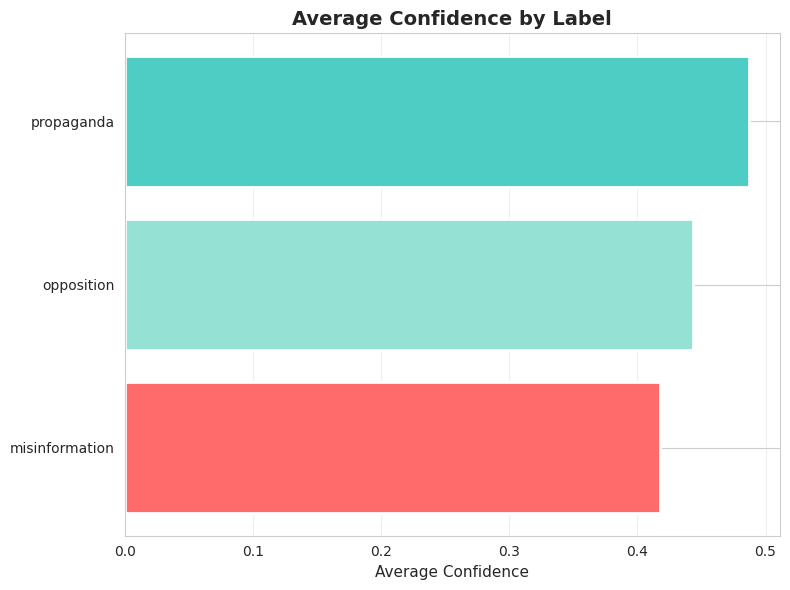

In [38]:
fig, ax = plt.subplots(figsize=(8, 6))

conf_by_label = results_df.groupby('final_label')['confidence'].mean().sort_values()
bar_colors = ['#FF6B6B' if l == 'misinformation' else '#4ECDC4' if l == 'propaganda' else '#95E1D3'
              for l in conf_by_label.index]
ax.barh(conf_by_label.index, conf_by_label.values, color=bar_colors, edgecolor='white', linewidth=2)
ax.set_title('Average Confidence by Label', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Confidence', fontsize=11)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('confidence_by_label.png', dpi=300, bbox_inches='tight')
plt.show()


In [39]:
low_conf = results_df[results_df['confidence'] < 0.6].sort_values('confidence')
print(f"\nLow Confidence Predictions ({len(low_conf)} cases):")
if len(low_conf) > 0:
    print(low_conf[['date', 'final_label', 'confidence', 'description']].head(10))
else:
    print("None found")


Low Confidence Predictions (399 cases):
          date     final_label  confidence  \
12  2022-03-08      propaganda    0.344846   
175 2023-02-24      opposition    0.351311   
3   2022-02-27  misinformation    0.351418   
365 2025-03-02      opposition    0.354528   
360 2025-02-24  misinformation    0.358337   
22  2022-03-18  misinformation    0.358529   
247 2023-08-14  misinformation    0.359934   
269 2023-10-10      propaganda    0.362874   
292 2024-02-01      opposition    0.363319   
130 2022-11-14  misinformation    0.363791   

                                           description  
12   In a Facebook post, the chief of staff of Ukra...  
175  First anniversary of Russia’s invasion into Uk...  
3    Responding to claims that the Russia is “ready...  
365  Keir Starmer hosts 18 world leaders at a summi...  
360  A dozen foreign leaders visit Kyiv to mark the...  
22   Russia Today has its licence to broadcast in t...  
247  Twenty-two Russian diplomats leave Moldova, as..